# Calibrating doline detection against manually mapped points

`DepthInSink` (notebooks 01/02) conflates slope roughness with real dolines. `DevFromMeanElev` (local relief relative to a neighborhood window) should cancel the regional slope out. This notebook calibrates window size + threshold against manually mapped ground truth (`data/manual/Sinkholes.shp`), using leave-one-out cross-validation so the result isn't just overfit to the same points it's picked from, and checks whether combining it with `DepthInSink` (real closed sink, not just a linear low spot) helps.

Goal is a defensible first-pass detector, not a finished method — 19 points is still a modest calibration set.

In [1]:
import os
from pathlib import Path


def _find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists():
            return p
    raise FileNotFoundError("pyproject.toml not found in any parent directory")


os.chdir(_find_repo_root(Path.cwd()))

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from master_thesis.dolines import (
    compute_depth_raster,
    compute_dev_from_mean_elev,
    random_points_in_polygon,
    sample_raster,
)

DATE = "20250820"
CLIPPED_DEM = Path(f"data/interim/{DATE}_terra_ppk_lidar_dsm_clip.tif")
AOI = Path(f"data/raw/{DATE}/{DATE}_aoi.gpkg")
MANUAL_POINTS = Path("data/manual/Sinkholes.shp")
INTERIM = Path("data/interim")
FIGURES = Path("outputs/figures")

WINDOW_WIDTHS_M = [0.5, 1, 1.5, 2, 3, 4, 5, 6, 8, 10]
PX_SIZE_M = 0.05
N_BACKGROUND = 300
SEED = 0
THRESHOLDS = np.arange(-2.0, 0.0, 0.02)

In [2]:
aoi = gpd.read_file(AOI)
manual_points = gpd.read_file(MANUAL_POINTS).to_crs(aoi.crs)
print(f"{len(manual_points)} manually mapped points")

background = random_points_in_polygon(
    aoi.union_all(), n=N_BACKGROUND, crs=aoi.crs,
    exclude=manual_points.geometry, exclude_buffer_m=2.0, seed=SEED,
)
print(f"{len(background)} background points")

depth_path = INTERIM / f"{CLIPPED_DEM.stem}_depth.tif"
if not depth_path.exists():
    compute_depth_raster(CLIPPED_DEM, depth_path)

manual_vals = pd.DataFrame({"depth": sample_raster(depth_path, manual_points)})
background_vals = pd.DataFrame({"depth": sample_raster(depth_path, background)})

for width_m in WINDOW_WIDTHS_M:
    filter_px = int(round(width_m / PX_SIZE_M)) | 1  # force odd
    dev_path = INTERIM / f"{CLIPPED_DEM.stem}_dev{filter_px}.tif"
    if not dev_path.exists():
        compute_dev_from_mean_elev(CLIPPED_DEM, dev_path, filter_px)
    manual_vals[width_m] = sample_raster(dev_path, manual_points)
    background_vals[width_m] = sample_raster(dev_path, background)

manual_vals.head()

19 manually mapped points
300 background points


,depth,0.5,1,1.5,2,3,4,5,6,8,10
0,0.000000,0.009460,0.019507,0.024977,0.041079,0.058227,0.076715,0.087207,0.084632,0.019252,-0.087449
1,0.000000,0.020172,0.021199,0.008929,0.004105,0.011054,0.014921,0.007002,-0.032083,-0.155430,-0.266258
2,1.175537,-0.035385,-0.121385,-0.276614,-0.421277,-0.659078,-0.858467,-1.027933,-1.165613,-1.368513,-1.470698
3,4.156494,-0.110938,-0.221006,-0.331955,-0.506164,-0.966076,-1.384957,-1.689890,-1.903652,-2.205461,-2.452159
4,1.058350,0.007050,-0.171244,-0.183661,-0.170070,-0.167690,-0.224555,-0.317998,-0.423452,-0.611689,-0.804340


## Best window/threshold per window (Youden's J = recall - false positive rate)

Fit on all 19 points first, just to see the shape — the real answer is the leave-one-out result below.

In [3]:
def best_threshold(manual_col: np.ndarray, background_col: np.ndarray, thresholds: np.ndarray):
    recalls = np.array([(manual_col < t).mean() for t in thresholds])
    fprs = np.array([(background_col < t).mean() for t in thresholds])
    j = recalls - fprs
    i = j.argmax()
    return thresholds[i], recalls[i], fprs[i], j[i]


summary = []
for w in WINDOW_WIDTHS_M:
    t, recall, fpr, j = best_threshold(manual_vals[w].to_numpy(), background_vals[w].to_numpy(), THRESHOLDS)
    summary.append({"window_m": w, "best_threshold": t, "recall": recall, "background_fpr": fpr, "youden_j": j})

summary_df = pd.DataFrame(summary)
summary_df

,window_m,best_threshold,recall,background_fpr,youden_j
0,0.5,-0.52,0.421053,0.010000,0.411053
1,1.0,-0.16,0.684211,0.173333,0.510877
2,1.5,-0.26,0.684211,0.090000,0.594211
3,2.0,-0.34,0.684211,0.056667,0.627544
4,3.0,-0.14,0.894737,0.173333,0.721404
5,4.0,-0.22,0.842105,0.110000,0.732105
6,5.0,-0.20,0.842105,0.140000,0.702105
7,6.0,-0.38,0.736842,0.060000,0.676842
8,8.0,-0.44,0.736842,0.056667,0.680175
9,10.0,-0.40,0.736842,0.056667,0.680175


## Leave-one-out cross-validation

For each manual point, pick the best (window, threshold) using the *other* 18 points + background only, then check whether the held-out point would actually be caught. Avoids picking a threshold that's just overfit to these exact 19 points.

In [4]:
loocv_hits = []
loocv_choices = []
for i in range(len(manual_vals)):
    train = manual_vals.drop(index=i)
    held_out = manual_vals.loc[i]

    best_j, best_w, best_t = -1.0, None, None
    for w in WINDOW_WIDTHS_M:
        t, _, _, j = best_threshold(train[w].to_numpy(), background_vals[w].to_numpy(), THRESHOLDS)
        if j > best_j:
            best_j, best_w, best_t = j, w, t

    hit = held_out[best_w] < best_t
    loocv_hits.append(hit)
    loocv_choices.append({"held_out_idx": i, "chosen_window": best_w, "chosen_threshold": best_t, "hit": hit})

loocv_df = pd.DataFrame(loocv_choices)
loocv_recall = loocv_df["hit"].mean()
print(f"leave-one-out recall: {loocv_recall:.0%} ({loocv_df['hit'].sum()}/{len(loocv_df)})")
print("most commonly chosen window:", loocv_df["chosen_window"].mode().iloc[0], "m")
loocv_df["chosen_window"].value_counts()

leave-one-out recall: 79% (15/19)
most commonly chosen window: 4 m


chosen_window
4    18
3     1
Name: count, dtype: int64

## Does adding a closedness check (DepthInSink) reduce false positives?

Real dolines should be actual closed sinks, not just locally-low spots (a linear gully would trip DevFromMeanElev too). Check recall/FPR for DevFromMeanElev alone vs. combined with DepthInSink at the modal LOOCV window.

In [5]:
best_window = loocv_df["chosen_window"].mode().iloc[0]
dev_threshold, _, _, _ = best_threshold(
    manual_vals[best_window].to_numpy(), background_vals[best_window].to_numpy(), THRESHOLDS
)

depth_thresholds = np.arange(0.0, 1.0, 0.02)
combo_results = []
for dt in depth_thresholds:
    m_hit = (manual_vals[best_window] < dev_threshold) & (manual_vals["depth"] > dt)
    b_hit = (background_vals[best_window] < dev_threshold) & (background_vals["depth"] > dt)
    combo_results.append({
        "depth_threshold": dt,
        "recall": m_hit.mean(),
        "background_fpr": b_hit.mean(),
        "youden_j": m_hit.mean() - b_hit.mean(),
    })

combo_df = pd.DataFrame(combo_results)
dev_only_recall = (manual_vals[best_window] < dev_threshold).mean()
dev_only_fpr = (background_vals[best_window] < dev_threshold).mean()
print(f"DevFromMeanElev alone (window={best_window}m, threshold={dev_threshold:.2f}): "
      f"recall={dev_only_recall:.0%}, background_fpr={dev_only_fpr:.0%}")
print()
print("combined with DepthInSink (best 5 depth thresholds by Youden's J):")
combo_df.sort_values("youden_j", ascending=False).head()

DevFromMeanElev alone (window=4m, threshold=-0.22): recall=84%, background_fpr=11%

combined with DepthInSink (best 5 depth thresholds by Youden's J):


,depth_threshold,recall,background_fpr,youden_j
4,0.08,0.526316,0.016667,0.509649
3,0.06,0.526316,0.016667,0.509649
2,0.04,0.526316,0.023333,0.502982
1,0.02,0.526316,0.023333,0.502982
0,0.00,0.526316,0.026667,0.499649


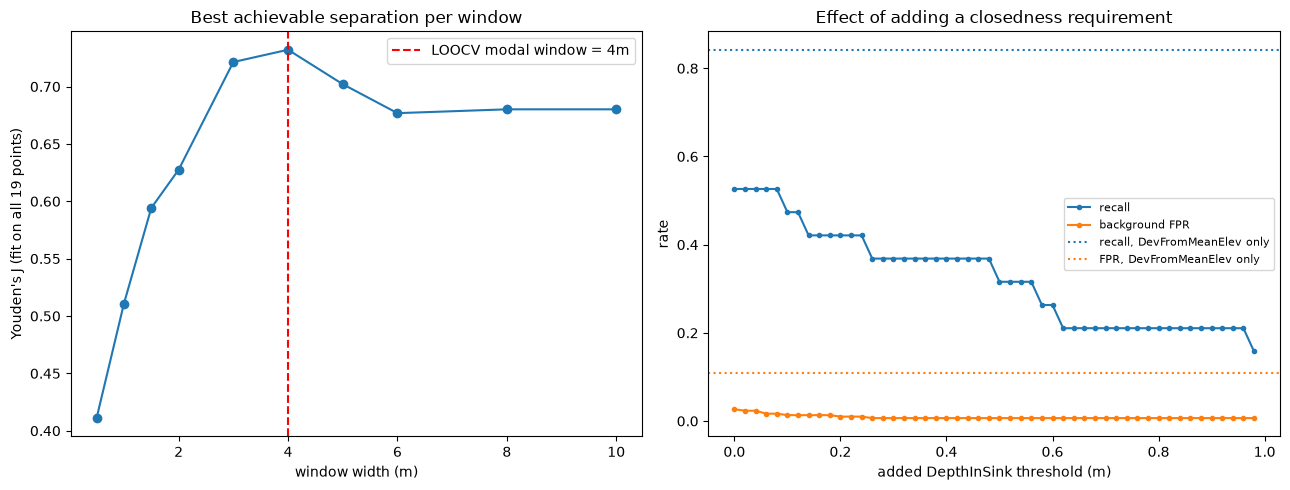

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(summary_df["window_m"], summary_df["youden_j"], marker="o")
axes[0].set_xlabel("window width (m)")
axes[0].set_ylabel("Youden's J (fit on all 19 points)")
axes[0].set_title("Best achievable separation per window")
axes[0].axvline(best_window, color="red", linestyle="--", label=f"LOOCV modal window = {best_window}m")
axes[0].legend()

axes[1].plot(combo_df["depth_threshold"], combo_df["recall"], label="recall", marker=".")
axes[1].plot(combo_df["depth_threshold"], combo_df["background_fpr"], label="background FPR", marker=".")
axes[1].axhline(dev_only_recall, color="C0", linestyle=":", label="recall, DevFromMeanElev only")
axes[1].axhline(dev_only_fpr, color="C1", linestyle=":", label="FPR, DevFromMeanElev only")
axes[1].set_xlabel("added DepthInSink threshold (m)")
axes[1].set_ylabel("rate")
axes[1].set_title("Effect of adding a closedness requirement")
axes[1].legend(fontsize=8)

fig.tight_layout()
fig.savefig(FIGURES / f"{DATE}_calibration_v2.png", dpi=150, bbox_inches="tight")
plt.show()